In [1]:
# A1 - AI Tool Used: ChatGPT

import pandas as pd
import numpy as np
from collections import Counter


cols = [
    "Class",
    "Alcohol",
    "Malicacid",
    "Ash",
    "Alcalinity_of_ash",
    "Magnesium",
    "Total_phenols",
    "Flavanoids",
    "Nonflavanoid_phenols",
    "Proanthocyanins",
    "Color_intensity",
    "Hue",
    "OD280_OD315",
    "Proline"
]


def distance(a, b):

    return np.linalg.norm(
        np.array(a) - np.array(b)
    )


def merge_sort(arr):

    if len(arr) <= 1:
        return arr

    middle = len(arr) // 2

    left = merge_sort(arr[:middle])
    right = merge_sort(arr[middle:])

    result = []

    i = 0
    j = 0

    while i < len(left) and j < len(right):

        if left[i][0] <= right[j][0]:

            result.append(left[i])
            i += 1

        else:

            result.append(right[j])
            j += 1

    result.extend(left[i:])
    result.extend(right[j:])

    return result


def quick_sort(arr):

    if len(arr) <= 1:
        return arr

    pivot = arr[-1][0]

    left = []
    middle = []
    right = []

    for item in arr:

        if item[0] < pivot:
            left.append(item)

        elif item[0] == pivot:
            middle.append(item)

        else:
            right.append(item)

    return (
        quick_sort(left)
        + middle
        + quick_sort(right)
    )


def heapify(arr, n, i):

    largest = i

    left = 2 * i + 1
    right = 2 * i + 2

    if left < n and arr[left][0] > arr[largest][0]:
        largest = left

    if right < n and arr[right][0] > arr[largest][0]:
        largest = right

    if largest != i:

        arr[i], arr[largest] = (
            arr[largest],
            arr[i]
        )

        heapify(arr, n, largest)


def heap_sort(arr):

    arr = arr.copy()

    n = len(arr)

    for i in range(n // 2 - 1, -1, -1):

        heapify(arr, n, i)

    for i in range(n - 1, 0, -1):

        arr[0], arr[i] = (
            arr[i],
            arr[0]
        )

        heapify(arr, i, 0)

    return arr


def sort_neighbors(arr, algorithm):

    if algorithm == "merge":

        return merge_sort(arr)

    elif algorithm == "quick":

        return quick_sort(arr)

    elif algorithm == "heap":

        return heap_sort(arr)

    else:

        return merge_sort(arr)


def find_neighbors(train_data, test_point):

    train_array = np.array(train_data)

    labels = train_array[:, 0]

    features = train_array[:, 1:].astype(float)

    test_point = np.array(
        test_point,
        dtype=float
    )

    distances = np.linalg.norm(
        features - test_point,
        axis=1
    )

    neighbors = []

    for i in range(len(distances)):

        neighbors.append(
            [distances[i], labels[i]]
        )

    return neighbors


def k_nearest_neighbors(
    neighbors,
    k,
    algorithm
):

    sorted_neighbors = sort_neighbors(
        neighbors,
        algorithm
    )

    return sorted_neighbors[:k]


def predict_class(neighbors):

    labels = []

    for neighbor in neighbors:

        labels.append(neighbor[1])

    counts = Counter(labels)

    highest_count = max(
        counts.values()
    )

    tied_labels = []

    for label in counts:

        if counts[label] == highest_count:

            tied_labels.append(label)

    if len(tied_labels) == 1:

        return tied_labels[0]

    for neighbor in neighbors:

        if neighbor[1] in tied_labels:

            return neighbor[1]


df = pd.read_csv(
    "wine.data",
    header=None,
    names=cols
)


data = df.values.tolist()

train_data = data[:150]

test_data = data[150:]


k = 5

sorting_algorithm = "merge"


print("A1 - AI Assisted kNN")

print(
    "Sorting Algorithm =",
    sorting_algorithm
)

print(
    "k =",
    k
)

print()


for i in range(len(test_data)):

    test_row = test_data[i]

    actual_class = test_row[0]

    test_point = test_row[1:]


    neighbors = find_neighbors(
        train_data,
        test_point
    )


    k_neighbors = k_nearest_neighbors(
        neighbors,
        k,
        sorting_algorithm
    )


    prediction = predict_class(
        k_neighbors
    )


    print(
        "Test Point =", i + 1,
        "Actual Class =", actual_class,
        "Predicted Class =", prediction
    )

A1 - AI Assisted kNN
Sorting Algorithm = merge
k = 5

Test Point = 1 Actual Class = 3.0 Predicted Class = 3.0
Test Point = 2 Actual Class = 3.0 Predicted Class = 2.0
Test Point = 3 Actual Class = 3.0 Predicted Class = 2.0
Test Point = 4 Actual Class = 3.0 Predicted Class = 2.0
Test Point = 5 Actual Class = 3.0 Predicted Class = 3.0
Test Point = 6 Actual Class = 3.0 Predicted Class = 3.0
Test Point = 7 Actual Class = 3.0 Predicted Class = 2.0
Test Point = 8 Actual Class = 3.0 Predicted Class = 2.0
Test Point = 9 Actual Class = 3.0 Predicted Class = 2.0
Test Point = 10 Actual Class = 3.0 Predicted Class = 2.0
Test Point = 11 Actual Class = 3.0 Predicted Class = 2.0
Test Point = 12 Actual Class = 3.0 Predicted Class = 2.0
Test Point = 13 Actual Class = 3.0 Predicted Class = 2.0
Test Point = 14 Actual Class = 3.0 Predicted Class = 2.0
Test Point = 15 Actual Class = 3.0 Predicted Class = 2.0
Test Point = 16 Actual Class = 3.0 Predicted Class = 2.0
Test Point = 17 Actual Class = 3.0 Predicte

In [2]:
# A2 - AI Tool Used: ChatGPT

from collections import defaultdict


def weighted_vote(neighbors):

    weights = defaultdict(float)

    for distance_value, label in neighbors:

        if distance_value == 0:
            weights[label] += float("inf")
        else:
            weights[label] += 1 / distance_value

    highest_weight = max(weights.values())

    tied_labels = [
        label
        for label in weights
        if weights[label] == highest_weight
    ]

    if len(tied_labels) == 1:
        return tied_labels[0]

    for distance_value, label in neighbors:

        if label in tied_labels:
            return label


neighbors = [
    [0.5, 1],
    [1.0, 2],
    [2.0, 2]
]

prediction = weighted_vote(neighbors)

print("A2 - WEIGHTED kNN")

print("Weighted kNN Prediction =", prediction)

A2 - WEIGHTED kNN
Weighted kNN Prediction = 1


In [3]:
# A3 - AI Tool Used: ChatGPT

import pandas as pd
from sklearn.model_selection import train_test_split


def prepare_data(data_frame):

    data = data_frame.values.tolist()

    selected_data = []

    for row in data:

        if row[0] == 1 or row[0] == 2:

            selected_data.append(row)

    X = []
    y = []

    for row in selected_data:

        y.append(row[0])

        X.append(row[1:])

    return X, y


def split_data(X, y):

    return train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=42
    )


data_frame = pd.read_csv("wine.csv")

X, y = prepare_data(data_frame)

X_train, X_test, y_train, y_test = split_data(X, y)


print("A3 - TRAIN / TEST SPLIT")

print("Total Samples =", len(X))

print("Training Samples =", len(X_train))

print("Testing Samples =", len(X_test))

print()

print("Training Labels =")
print(y_train)

print()

print("Testing Labels =")
print(y_test)

A3 - TRAIN / TEST SPLIT
Total Samples = 130
Training Samples = 91
Testing Samples = 39

Training Labels =
[1.0, 1.0, 2.0, 2.0, 1.0, 2.0, 2.0, 1.0, 1.0, 2.0, 1.0, 2.0, 1.0, 2.0, 2.0, 1.0, 1.0, 2.0, 2.0, 1.0, 1.0, 1.0, 1.0, 2.0, 1.0, 2.0, 1.0, 1.0, 2.0, 2.0, 2.0, 1.0, 1.0, 2.0, 1.0, 1.0, 1.0, 2.0, 2.0, 1.0, 2.0, 2.0, 2.0, 1.0, 1.0, 2.0, 1.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 1.0, 1.0, 2.0, 1.0, 2.0, 2.0, 1.0, 2.0, 1.0, 2.0, 2.0, 2.0, 2.0, 1.0, 1.0, 2.0, 2.0, 1.0, 1.0, 1.0, 1.0, 1.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 1.0, 2.0, 2.0, 2.0, 1.0, 2.0, 2.0]

Testing Labels =
[1.0, 1.0, 1.0, 1.0, 2.0, 1.0, 2.0, 2.0, 2.0, 1.0, 2.0, 1.0, 2.0, 1.0, 2.0, 2.0, 1.0, 2.0, 2.0, 2.0, 1.0, 1.0, 2.0, 1.0, 2.0, 1.0, 2.0, 2.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 2.0, 2.0, 2.0, 1.0, 2.0]


In [4]:
# A4 - AI Tool Used: ChatGPT

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier


def prepare_data(data_frame):

    selected_data = data_frame[
        data_frame["Class"].isin([1, 2])
    ]

    X = selected_data.drop(
        columns=["Class"]
    )

    y = selected_data["Class"]

    return X, y


def train_knn(X_train, y_train, k):

    model = KNeighborsClassifier(
        n_neighbors=k,
        algorithm="auto"
    )

    model.fit(
        X_train,
        y_train
    )

    return model


df = pd.read_csv("wine.csv")

X, y = prepare_data(df)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

neigh = train_knn(
    X_train,
    y_train,
    3
)


print("A4 - TRAIN kNN WITH k = 3")

print("kNN classifier trained successfully.")

print("Value of k =", 3)

print("Training samples =", len(X_train))

print("Testing samples =", len(X_test))

A4 - TRAIN kNN WITH k = 3
kNN classifier trained successfully.
Value of k = 3
Training samples = 91
Testing samples = 39


In [5]:
# A5 - AI Tool Used: ChatGPT

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier


def calculate_accuracy(model, X_test, y_test):

    return model.score(
        X_test,
        y_test
    )


data_frame = pd.read_csv("wine.csv")

data = data_frame.values.tolist()

selected_data = []

for row in data:

    if row[0] == 1 or row[0] == 2:

        selected_data.append(row)


X = []
y = []

for row in selected_data:

    y.append(row[0])
    X.append(row[1:])


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)


neigh = KNeighborsClassifier(
    n_neighbors=3
)

neigh.fit(
    X_train,
    y_train
)


accuracy = calculate_accuracy(
    neigh,
    X_test,
    y_test
)


print("A5 - TEST ACCURACY")

print("k =", 3)

print("Accuracy =", accuracy)

print(
    "Accuracy Percentage =",
    accuracy * 100,
    "%"
)

A5 - TEST ACCURACY
k = 3
Accuracy = 0.8974358974358975
Accuracy Percentage = 89.74358974358975 %


In [6]:
# A6 - AI Tool Used: ChatGPT

def predict_test_vectors(model, X_test):

    return model.predict(X_test)


predictions = predict_test_vectors(
    neigh,
    X_test
)


print("A6 - PREDICT TEST VECTORS")

for i in range(len(X_test)):

    print(
        "Test Point =", i + 1,
        "Actual Class =", y_test[i],
        "Predicted Class =", predictions[i]
    )

A6 - PREDICT TEST VECTORS
Test Point = 1 Actual Class = 1.0 Predicted Class = 1.0
Test Point = 2 Actual Class = 1.0 Predicted Class = 1.0
Test Point = 3 Actual Class = 1.0 Predicted Class = 1.0
Test Point = 4 Actual Class = 1.0 Predicted Class = 1.0
Test Point = 5 Actual Class = 2.0 Predicted Class = 2.0
Test Point = 6 Actual Class = 1.0 Predicted Class = 1.0
Test Point = 7 Actual Class = 2.0 Predicted Class = 1.0
Test Point = 8 Actual Class = 2.0 Predicted Class = 2.0
Test Point = 9 Actual Class = 2.0 Predicted Class = 2.0
Test Point = 10 Actual Class = 1.0 Predicted Class = 1.0
Test Point = 11 Actual Class = 2.0 Predicted Class = 1.0
Test Point = 12 Actual Class = 1.0 Predicted Class = 1.0
Test Point = 13 Actual Class = 2.0 Predicted Class = 2.0
Test Point = 14 Actual Class = 1.0 Predicted Class = 1.0
Test Point = 15 Actual Class = 2.0 Predicted Class = 2.0
Test Point = 16 Actual Class = 2.0 Predicted Class = 2.0
Test Point = 17 Actual Class = 1.0 Predicted Class = 1.0
Test Point = 1

In [7]:
# A7 - AI Tool Used: ChatGPT

import numpy as np
from collections import Counter


def distance(a, b):

    return np.linalg.norm(
        np.array(a) - np.array(b)
    )


def find_neighbors(
    training_features,
    training_labels,
    test_point
):

    training_features = np.array(
        training_features,
        dtype=float
    )

    test_point = np.array(
        test_point,
        dtype=float
    )

    distances = np.linalg.norm(
        training_features - test_point,
        axis=1
    )

    neighbors = []

    for i in range(len(distances)):

        neighbors.append(
            [
                distances[i],
                training_labels[i]
            ]
        )

    return neighbors


def predict_class(neighbors):

    labels = []

    for neighbor in neighbors:

        labels.append(neighbor[1])

    counts = Counter(labels)

    highest_count = max(
        counts.values()
    )

    tied_labels = []

    for label in counts:

        if counts[label] == highest_count:

            tied_labels.append(label)

    if len(tied_labels) == 1:

        return tied_labels[0]

    for neighbor in neighbors:

        if neighbor[1] in tied_labels:

            return neighbor[1]


def fit(
    training_features,
    training_labels,
    k
):

    model = [
        training_features,
        training_labels,
        k
    ]

    return model


def predict(
    model,
    test_features
):

    training_features = model[0]

    training_labels = model[1]

    k = model[2]

    predictions = []

    for test_point in test_features:

        neighbors = find_neighbors(
            training_features,
            training_labels,
            test_point
        )

        neighbors.sort(
            key=lambda x: x[0]
        )

        k_neighbors = neighbors[:k]

        prediction = predict_class(
            k_neighbors
        )

        predictions.append(
            prediction
        )

    return predictions


def score(
    model,
    test_features,
    actual_labels
):

    predictions = predict(
        model,
        test_features
    )

    accuracy = np.mean(
        np.array(predictions) ==
        np.array(actual_labels)
    )

    return accuracy


training_features = [
    [1.0, 2.0],
    [1.2, 1.8],
    [5.0, 6.0],
    [5.2, 5.8]
]

training_labels = [
    1, 1, 2, 2
]

test_features = [
    [1.1, 2.1],
    [5.1, 6.1]
]

test_labels = [
    1, 2
]


model = fit(
    training_features,
    training_labels,
    k=3
)


predictions = predict(
    model,
    test_features
)


accuracy = score(
    model,
    test_features,
    test_labels
)


print("A7")

print(
    "Predictions =",
    predictions
)

print(
    "Actual Labels =",
    test_labels
)

print(
    "Accuracy =",
    accuracy
)

A7
Predictions = [1, 2]
Actual Labels = [1, 2]
Accuracy = 1.0


A8 - CUSTOM kNN vs PACKAGE kNN

k = 1 Custom = 0.8974358974358975 Package = 0.8974358974358975
k = 2 Custom = 0.8974358974358975 Package = 0.8974358974358975
k = 3 Custom = 0.8974358974358975 Package = 0.8974358974358975
k = 4 Custom = 0.8974358974358975 Package = 0.8974358974358975
k = 5 Custom = 0.9230769230769231 Package = 0.9230769230769231
k = 6 Custom = 0.8974358974358975 Package = 0.8974358974358975
k = 7 Custom = 0.9230769230769231 Package = 0.9230769230769231
k = 8 Custom = 0.8717948717948718 Package = 0.8974358974358975
k = 9 Custom = 0.8974358974358975 Package = 0.8974358974358975
k = 10 Custom = 0.8974358974358975 Package = 0.8974358974358975
k = 11 Custom = 0.9230769230769231 Package = 0.9230769230769231
k = 12 Custom = 0.9230769230769231 Package = 0.9230769230769231
k = 13 Custom = 0.9230769230769231 Package = 0.9230769230769231
k = 14 Custom = 0.9230769230769231 Package = 0.9230769230769231
k = 15 Custom = 0.9230769230769231 Package = 0.9230769230769231
k = 16 Custom = 0

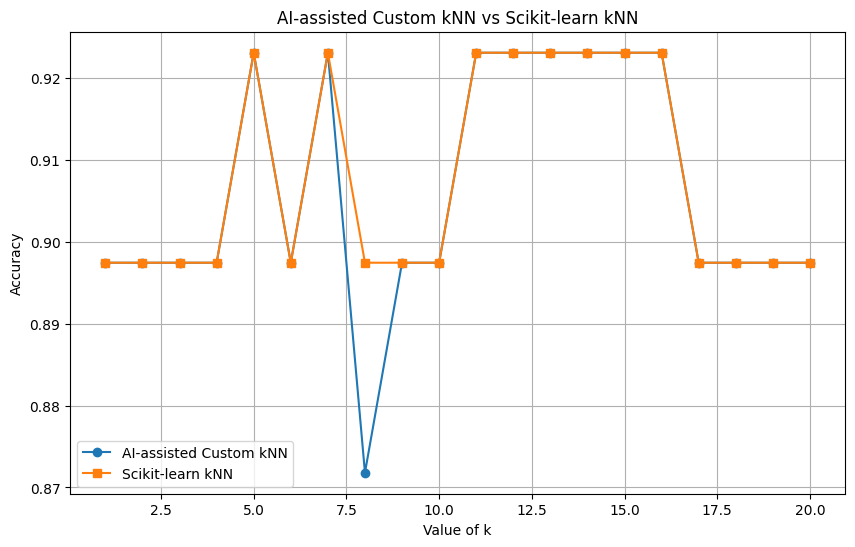

In [8]:
# A8 - AI Tool Used: ChatGPT

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier


def distance(a, b):

    return np.linalg.norm(
        np.array(a) - np.array(b)
    )


def find_neighbors(
    train_data,
    test_point
):

    train_data = np.array(
        train_data,
        dtype=float
    )

    test_point = np.array(
        test_point,
        dtype=float
    )

    labels = train_data[:, 0]

    features = train_data[:, 1:]

    distances = np.linalg.norm(
        features - test_point,
        axis=1
    )

    neighbors = np.column_stack(
        (distances, labels)
    ).tolist()

    return neighbors


def k_nearest_neighbors(
    neighbors,
    k
):

    neighbors = sorted(
        neighbors,
        key=lambda x: x[0]
    )

    return neighbors[:k]


def predict_class(
    neighbors
):

    labels = [
        neighbor[1]
        for neighbor in neighbors
    ]

    unique_labels = np.unique(
        labels
    )

    counts = {}

    for label in unique_labels:

        counts[label] = labels.count(
            label
        )

    highest_count = max(
        counts.values()
    )

    tied_labels = [
        label
        for label in counts
        if counts[label] == highest_count
    ]

    if len(tied_labels) == 1:

        return tied_labels[0]

    for neighbor in neighbors:

        if neighbor[1] in tied_labels:

            return neighbor[1]


def fit(
    X_train,
    y_train,
    k
):

    model = {
        "X_train": np.array(
            X_train,
            dtype=float
        ),

        "y_train": np.array(
            y_train
        ),

        "k": k
    }

    return model


def predict(
    model,
    X_test
):

    X_train = model["X_train"]

    y_train = model["y_train"]

    k = model["k"]

    predictions = []

    train_data = np.column_stack(
        (y_train, X_train)
    )

    for test_point in X_test:

        neighbors = find_neighbors(
            train_data,
            test_point
        )

        k_neighbors = k_nearest_neighbors(
            neighbors,
            k
        )

        prediction = predict_class(
            k_neighbors
        )

        predictions.append(
            prediction
        )

    return predictions


def score(
    model,
    X_test,
    y_test
):

    predictions = predict(
        model,
        X_test
    )

    predictions = np.array(
        predictions
    )

    y_test = np.array(
        y_test
    )

    return np.mean(
        predictions == y_test
    )


data_frame = pd.read_csv(
    "wine.csv"
)

data = data_frame.values.tolist()


selected_data = [
    row
    for row in data
    if row[0] == 1 or row[0] == 2
]


X = [
    row[1:]
    for row in selected_data
]

y = [
    row[0]
    for row in selected_data
]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)


k_values = list(
    range(1, 21)
)

custom_accuracies = []

package_accuracies = []


for k in k_values:

    custom_model = fit(
        X_train,
        y_train,
        k
    )

    custom_accuracy = score(
        custom_model,
        X_test,
        y_test
    )

    custom_accuracies.append(
        custom_accuracy
    )


    package_model = KNeighborsClassifier(
        n_neighbors=k
    )

    package_model.fit(
        X_train,
        y_train
    )

    package_accuracy = package_model.score(
        X_test,
        y_test
    )

    package_accuracies.append(
        package_accuracy
    )


print("A8 - CUSTOM kNN vs PACKAGE kNN")

print()

for i in range(
    len(k_values)
):

    print(
        "k =", k_values[i],
        "Custom =", custom_accuracies[i],
        "Package =", package_accuracies[i]
    )


plt.figure(
    figsize=(10, 6)
)

plt.plot(
    k_values,
    custom_accuracies,
    marker="o",
    label="AI-assisted Custom kNN"
)

plt.plot(
    k_values,
    package_accuracies,
    marker="s",
    label="Scikit-learn kNN"
)

plt.xlabel(
    "Value of k"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "AI-assisted Custom kNN vs Scikit-learn kNN"
)

plt.legend()

plt.grid(True)

plt.show()

A9 - WEIGHTED vs NORMAL kNN
k = 1 Normal kNN = 0.8974358974358975 Weighted kNN = 0.8974358974358975
k = 2 Normal kNN = 0.8974358974358975 Weighted kNN = 0.8974358974358975
k = 3 Normal kNN = 0.8974358974358975 Weighted kNN = 0.8974358974358975
k = 4 Normal kNN = 0.8974358974358975 Weighted kNN = 0.8974358974358975
k = 5 Normal kNN = 0.9230769230769231 Weighted kNN = 0.9230769230769231
k = 6 Normal kNN = 0.8974358974358975 Weighted kNN = 0.8974358974358975
k = 7 Normal kNN = 0.9230769230769231 Weighted kNN = 0.9230769230769231
k = 8 Normal kNN = 0.8717948717948718 Weighted kNN = 0.8717948717948718
k = 9 Normal kNN = 0.8974358974358975 Weighted kNN = 0.8974358974358975
k = 10 Normal kNN = 0.8974358974358975 Weighted kNN = 0.8974358974358975
k = 11 Normal kNN = 0.9230769230769231 Weighted kNN = 0.8974358974358975
k = 12 Normal kNN = 0.9230769230769231 Weighted kNN = 0.8974358974358975
k = 13 Normal kNN = 0.9230769230769231 Weighted kNN = 0.8974358974358975
k = 14 Normal kNN = 0.9230769230

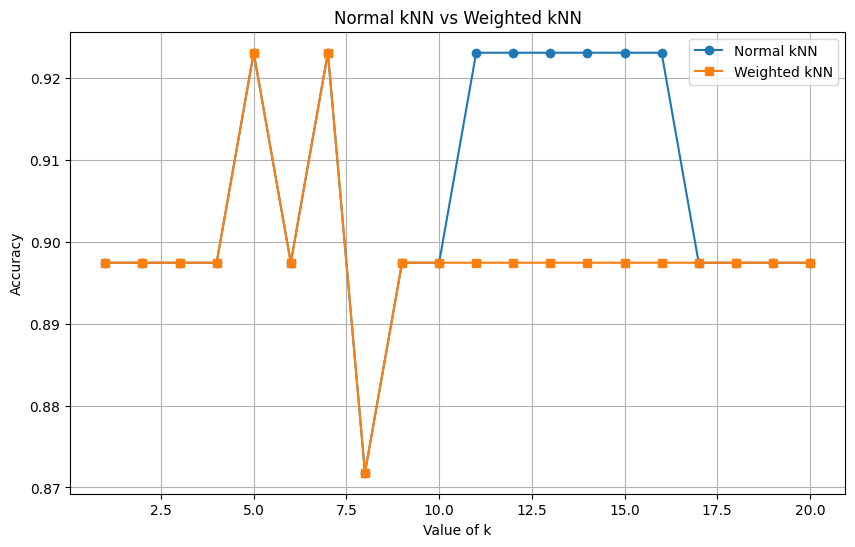

In [9]:
# A9 - AI Tool Used: ChatGPT

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from collections import Counter


def distance(a, b):

    return np.linalg.norm(
        np.array(a) - np.array(b)
    )


def find_neighbors(
    train_data,
    test_point
):

    train_data = np.array(
        train_data,
        dtype=float
    )

    test_point = np.array(
        test_point,
        dtype=float
    )

    labels = train_data[:, 0]

    features = train_data[:, 1:]

    distances = np.linalg.norm(
        features - test_point,
        axis=1
    )

    neighbors = np.column_stack(
        (distances, labels)
    ).tolist()

    return neighbors


def k_nearest_neighbors(
    neighbors,
    k
):

    neighbors = sorted(
        neighbors,
        key=lambda x: x[0]
    )

    return neighbors[:k]


def normal_vote(
    neighbors
):

    labels = [
        neighbor[1]
        for neighbor in neighbors
    ]

    counts = Counter(labels)

    highest_count = max(
        counts.values()
    )

    tied_labels = [
        label
        for label in counts
        if counts[label] == highest_count
    ]

    if len(tied_labels) == 1:

        return tied_labels[0]

    for neighbor in neighbors:

        if neighbor[1] in tied_labels:

            return neighbor[1]


def weighted_vote(
    neighbors
):

    weights = {}

    for distance_value, label in neighbors:

        if distance_value == 0:

            weight = float("inf")

        else:

            weight = 1 / distance_value

        weights[label] = (
            weights.get(label, 0)
            + weight
        )

    highest_weight = max(
        weights.values()
    )

    tied_labels = [
        label
        for label in weights
        if weights[label] == highest_weight
    ]

    if len(tied_labels) == 1:

        return tied_labels[0]

    for neighbor in neighbors:

        if neighbor[1] in tied_labels:

            return neighbor[1]


def predict_normal(
    X_train,
    y_train,
    X_test,
    k
):

    predictions = []

    training_data = np.column_stack(
        (
            y_train,
            X_train
        )
    ).tolist()

    for test_point in X_test:

        neighbors = find_neighbors(
            training_data,
            test_point
        )

        k_neighbors = k_nearest_neighbors(
            neighbors,
            k
        )

        prediction = normal_vote(
            k_neighbors
        )

        predictions.append(
            prediction
        )

    return predictions


def predict_weighted(
    X_train,
    y_train,
    X_test,
    k
):

    predictions = []

    training_data = np.column_stack(
        (
            y_train,
            X_train
        )
    ).tolist()

    for test_point in X_test:

        neighbors = find_neighbors(
            training_data,
            test_point
        )

        k_neighbors = k_nearest_neighbors(
            neighbors,
            k
        )

        prediction = weighted_vote(
            k_neighbors
        )

        predictions.append(
            prediction
        )

    return predictions


def calculate_accuracy(
    predictions,
    actual_labels
):

    predictions = np.array(
        predictions
    )

    actual_labels = np.array(
        actual_labels
    )

    return np.mean(
        predictions == actual_labels
    )


data_frame = pd.read_csv(
    "wine.csv"
)

data = data_frame.values.tolist()


selected_data = [
    row
    for row in data
    if row[0] == 1 or row[0] == 2
]


X = [
    row[1:]
    for row in selected_data
]

y = [
    row[0]
    for row in selected_data
]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)


k_values = list(
    range(1, 21)
)

normal_accuracies = []

weighted_accuracies = []


for k in k_values:

    normal_predictions = predict_normal(
        X_train,
        y_train,
        X_test,
        k
    )

    normal_accuracy = calculate_accuracy(
        normal_predictions,
        y_test
    )

    normal_accuracies.append(
        normal_accuracy
    )


    weighted_predictions = predict_weighted(
        X_train,
        y_train,
        X_test,
        k
    )

    weighted_accuracy = calculate_accuracy(
        weighted_predictions,
        y_test
    )

    weighted_accuracies.append(
        weighted_accuracy
    )


print("A9 - WEIGHTED vs NORMAL kNN")

for i in range(
    len(k_values)
):

    print(
        "k =", k_values[i],
        "Normal kNN =", normal_accuracies[i],
        "Weighted kNN =", weighted_accuracies[i]
    )


plt.figure(
    figsize=(10, 6)
)

plt.plot(
    k_values,
    normal_accuracies,
    marker="o",
    label="Normal kNN"
)

plt.plot(
    k_values,
    weighted_accuracies,
    marker="s",
    label="Weighted kNN"
)

plt.xlabel(
    "Value of k"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "Normal kNN vs Weighted kNN"
)

plt.legend()

plt.grid(True)

plt.show()

## A10 - Own (Manual) kNN Implementation
This is my own Lab 05 implementation (`distance`, `bubble_sort`, `find_neighbors`, `k_nearest_neighbors`, `predict_class_for_test_point`, `fit`, `predict`, `score`), copied in directly from `lab5_1.py` with no GenAI tool used. It is the *"code written by you"* baseline for the A3 performance comparison below.

In [ ]:
def distance(a, b):
    dist = 0
    for i in range(len(a)):
        dist += (a[i] - b[i]) ** 2
    return dist ** 0.5


def bubble_sort(arr, n):
    n = len(arr)
    for i in range(n):
        for j in range(n - i - 1):
            if arr[j][0] > arr[j + 1][0]:
                arr[j], arr[j + 1] = arr[j + 1], arr[j]
    return arr


def sort_neighbors(arr, algorithm):
    if algorithm == "bubble":
        return bubble_sort(arr, len(arr))
    else:
        return bubble_sort(arr, len(arr))


def find_neighbors(train_data, test_point):
    neighbors = []

    for row in train_data:
        label = row[0]
        train_point = row[1:]

        dist = distance(train_point, test_point)
        neighbors.append([dist, label])

    return neighbors


def k_nearest_neighbors(neighbors, k, algorithm="bubble"):
    neighbors = sort_neighbors(neighbors, algorithm)
    return neighbors[:k]


def predict_class_for_test_point(neighbors):
    labels = []
    counts = []

    for neighbor in neighbors:
        label = neighbor[1]
        found = False

        for i in range(len(labels)):
            if labels[i] == label:
                counts[i] += 1
                found = True
                break

        if not found:
            labels.append(label)
            counts.append(1)

    highest_count = counts[0]

    for count in counts:
        if count > highest_count:
            highest_count = count

    tied_labels = []

    for i in range(len(labels)):
        if counts[i] == highest_count:
            tied_labels.append(labels[i])

    if len(tied_labels) == 1:
        return tied_labels[0]

    # tie-break: closest tied neighbor
    for neighbor in neighbors:
        for label in tied_labels:
            if neighbor[1] == label:
                return label


def fit_own(training_features, training_labels, k):
    model = {
        "training_features": training_features,
        "training_labels": training_labels,
        "k": k,
    }
    return model


def predict_own(model, test_features):
    predictions = []

    training_data = []
    for i in range(len(model["training_features"])):
        training_data.append(
            [model["training_labels"][i]] + list(model["training_features"][i])
        )

    for test_point in test_features:
        neighbors = find_neighbors(training_data, test_point)
        k_neighbors = k_nearest_neighbors(neighbors, model["k"], "bubble")
        prediction = predict_class_for_test_point(k_neighbors)
        predictions.append(prediction)

    return predictions


def calculate_accuracy(predictions, actual_labels):
    correct_predictions = 0
    for i in range(len(actual_labels)):
        if predictions[i] == actual_labels[i]:
            correct_predictions += 1
    return correct_predictions / len(actual_labels)


def score_own(model, test_features, actual_labels):
    predictions = predict_own(model, test_features)
    return calculate_accuracy(predictions, actual_labels)


## A2 - Unit Test Cases
Unit tests were generated with AI assistance to validate the modular functions from **both** last week's (Lab 05, own/manual version) and this week's (Lab 06, AI-assisted version) implementations: `distance`, sorting/neighbor selection, `predict_class`/voting (majority + tie-breaking), and the `fit`/`predict`/`score` wrappers. A cross-implementation functional test checks that the own version and the AI-assisted version agree on identical input data.

In [1]:
# A2 - AI Tool Used: ChatGPT
# Unit test cases generated with AI assistance to test the modular functions
# built in Lab 05 (own version) and Lab 06 (AI-assisted version).

import unittest
import numpy as np

from own_knn import (
    distance as distance_own,
    bubble_sort as bubble_sort_own,
    find_neighbors as find_neighbors_own,
    k_nearest_neighbors as k_nearest_neighbors_own,
    predict_class_for_test_point as predict_class_own,
    fit_own,
    predict_own,
    score_own,
)

from a3_comparison import (
    distance,
    find_neighbors,
    predict_class,
    fit,
    predict,
    score,
)


# Lab 05 - Own (manual) implementation

class TestOwnDistance(unittest.TestCase):
    def test_distance_known_value(self):
        self.assertAlmostEqual(distance_own([0, 0], [3, 4]), 5.0)

    def test_distance_zero_for_identical_points(self):
        self.assertEqual(distance_own([1, 2, 3], [1, 2, 3]), 0.0)

    def test_distance_symmetry(self):
        self.assertAlmostEqual(
            distance_own([1, 2], [4, 6]), distance_own([4, 6], [1, 2])
        )


class TestOwnBubbleSort(unittest.TestCase):
    def test_sorts_ascending_by_distance(self):
        arr = [[3.0, "b"], [1.0, "a"], [2.0, "c"]]
        sorted_arr = bubble_sort_own(arr, len(arr))
        self.assertEqual([x[0] for x in sorted_arr], [1.0, 2.0, 3.0])

    def test_empty_list(self):
        self.assertEqual(bubble_sort_own([], 0), [])

    def test_single_element(self):
        self.assertEqual(bubble_sort_own([[1.0, "a"]], 1), [[1.0, "a"]])


class TestOwnFindNeighbors(unittest.TestCase):
    def test_returns_correct_count(self):
        train_data = [[1, 0, 0], [2, 3, 4], [1, 1, 1]]
        neighbors = find_neighbors_own(train_data, [0, 0])
        self.assertEqual(len(neighbors), 3)

    def test_nearest_point_has_smallest_distance(self):
        train_data = [[1, 0, 0], [2, 10, 10], [1, 0.1, 0.1]]
        neighbors = find_neighbors_own(train_data, [0, 0])
        nearest = min(neighbors, key=lambda n: n[0])
        self.assertEqual(nearest[1], 1)


class TestOwnPredictClass(unittest.TestCase):
    def test_majority_vote(self):
        neighbors = [[0.1, 1], [0.2, 1], [0.3, 2]]
        self.assertEqual(predict_class_own(neighbors), 1)

    def test_tie_breaks_to_closest_neighbor(self):
        neighbors = [[0.1, 2], [0.2, 1], [0.3, 2], [0.4, 1]]
        # counts tied 2-2 -> nearest neighbor (0.1 -> label 2) should win
        self.assertEqual(predict_class_own(neighbors), 2)


class TestOwnFitPredictScore(unittest.TestCase):
    def setUp(self):
        self.X_train = [[0, 0], [0, 1], [5, 5], [5, 6]]
        self.y_train = [1, 1, 2, 2]
        self.X_test = [[0.1, 0.1], [5.1, 5.1]]
        self.y_test = [1, 2]

    def test_predict_returns_correct_labels(self):
        model = fit_own(self.X_train, self.y_train, k=1)
        preds = predict_own(model, self.X_test)
        self.assertEqual(preds, [1, 2])

    def test_score_is_perfect_on_separable_data(self):
        model = fit_own(self.X_train, self.y_train, k=1)
        acc = score_own(model, self.X_test, self.y_test)
        self.assertEqual(acc, 1.0)


# Lab 06 - AI-assisted (GenAI) implementation
class TestAIDistance(unittest.TestCase):
    def test_distance_known_value(self):
        self.assertAlmostEqual(distance([0, 0], [3, 4]), 5.0)

    def test_distance_zero_for_identical_points(self):
        self.assertEqual(distance([2, 2], [2, 2]), 0.0)


class TestAIFindNeighbors(unittest.TestCase):
    def test_returns_correct_count_and_type(self):
        train_features = [[0, 0], [10, 10], [0.1, 0.1]]
        train_labels = [1, 2, 1]
        neighbors = find_neighbors(train_features, train_labels, [0, 0])
        self.assertEqual(len(neighbors), 3)
        self.assertIsInstance(neighbors[0][0], (float, np.floating))

    def test_nearest_point_identified_correctly(self):
        train_features = [[0, 0], [10, 10], [0.1, 0.1]]
        train_labels = [1, 2, 1]
        neighbors = find_neighbors(train_features, train_labels, [0, 0])
        nearest = min(neighbors, key=lambda n: n[0])
        self.assertEqual(nearest[1], 1)


class TestAIPredictClass(unittest.TestCase):
    def test_majority_vote(self):
        neighbors = [[0.1, 1], [0.2, 1], [0.3, 2]]
        self.assertEqual(predict_class(neighbors), 1)

    def test_tie_breaks_to_closest_neighbor(self):
        neighbors = [[0.1, 2], [0.2, 1], [0.3, 2], [0.4, 1]]
        self.assertEqual(predict_class(neighbors), 2)


class TestAIFitPredictScore(unittest.TestCase):
    def setUp(self):
        self.X_train = [[0, 0], [0, 1], [5, 5], [5, 6]]
        self.y_train = [1, 1, 2, 2]
        self.X_test = [[0.1, 0.1], [5.1, 5.1]]
        self.y_test = [1, 2]

    def test_predict_returns_correct_labels(self):
        model = fit(self.X_train, self.y_train, k=1)
        preds = predict(model, self.X_test)
        self.assertEqual(preds, [1, 2])

    def test_score_is_perfect_on_separable_data(self):
        model = fit(self.X_train, self.y_train, k=1)
        acc = score(model, self.X_test, self.y_test)
        self.assertEqual(acc, 1.0)


# Functional test - own vs AI-assisted vs scikit-learn agree on same data
class TestCrossImplementationAgreement(unittest.TestCase):
    def test_own_and_ai_versions_agree(self):
        X_train = [[0, 0], [1, 0], [0, 1], [5, 5], [6, 5], [5, 6]]
        y_train = [1, 1, 1, 2, 2, 2]
        X_test = [[0.5, 0.5], [5.5, 5.5]]

        own_model = fit_own(X_train, y_train, k=3)
        own_preds = predict_own(own_model, X_test)

        ai_model = fit(X_train, y_train, 3)
        ai_preds = predict(ai_model, X_test)

        self.assertEqual(own_preds, ai_preds)


if __name__ == "__main__":
    loader = unittest.TestLoader()
    suite = unittest.TestSuite()
    for test_class in [
        TestOwnDistance,
        TestOwnBubbleSort,
        TestOwnFindNeighbors,
        TestOwnPredictClass,
        TestOwnFitPredictScore,
        TestAIDistance,
        TestAIFindNeighbors,
        TestAIPredictClass,
        TestAIFitPredictScore,
        TestCrossImplementationAgreement,
    ]:
        suite.addTests(loader.loadTestsFromTestCase(test_class))

    runner = unittest.TextTestRunner(verbosity=2)
    result = runner.run(suite)

    print()
    print("A2 - UNIT TEST SUMMARY")
    print("Total tests run:", result.testsRun)
    print("Passed:", result.testsRun - len(result.failures) - len(result.errors))
    print("Failed:", len(result.failures))
    print("Errors:", len(result.errors))


test_distance_known_value (__main__.TestOwnDistance.test_distance_known_value) ... ok
test_distance_symmetry (__main__.TestOwnDistance.test_distance_symmetry) ... ok
test_distance_zero_for_identical_points (__main__.TestOwnDistance.test_distance_zero_for_identical_points) ... ok
test_empty_list (__main__.TestOwnBubbleSort.test_empty_list) ... ok
test_single_element (__main__.TestOwnBubbleSort.test_single_element) ... ok
test_sorts_ascending_by_distance (__main__.TestOwnBubbleSort.test_sorts_ascending_by_distance) ... ok
test_nearest_point_has_smallest_distance (__main__.TestOwnFindNeighbors.test_nearest_point_has_smallest_distance) ... ok
test_returns_correct_count (__main__.TestOwnFindNeighbors.test_returns_correct_count) ... ok
test_majority_vote (__main__.TestOwnPredictClass.test_majority_vote) ... ok
test_tie_breaks_to_closest_neighbor (__main__.TestOwnPredictClass.test_tie_breaks_to_closest_neighbor) ... ok
test_predict_returns_correct_labels (__main__.TestOwnFitPredictScore.test_


A2 - UNIT TEST SUMMARY
Total tests run: 21
Passed: 21
Failed: 0
Errors: 0


## A3 - Performance Comparison of 3 kNN Versions
Comparison of **(1)** the own/manual implementation above, **(2)** Scikit-learn's `KNeighborsClassifier`, and **(3)** the GenAI-generated `fit`/`predict`/`score` implementation from A7 — all evaluated on the same train/test split of the **project data (Wine dataset, all 178 samples, 3 classes)**, standardized before distance computation. For each version we report Accuracy, Precision, Recall, F-score (macro-averaged), and computational time averaged over 10 runs.

In [ ]:


import time
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from own_knn import fit_own, predict_own


# A7 - AI Tool Used: ChatGPT
def distance(a, b):
    return np.linalg.norm(np.array(a) - np.array(b))


def find_neighbors(training_features, training_labels, test_point):
    training_features = np.array(training_features, dtype=float)
    test_point = np.array(test_point, dtype=float)
    distances = np.linalg.norm(training_features - test_point, axis=1)
    neighbors = []
    for i in range(len(distances)):
        neighbors.append([distances[i], training_labels[i]])
    return neighbors


def predict_class(neighbors):
    labels = [n[1] for n in neighbors]
    counts = Counter(labels)
    highest_count = max(counts.values())
    tied_labels = [lbl for lbl in counts if counts[lbl] == highest_count]
    if len(tied_labels) == 1:
        return tied_labels[0]
    for n in neighbors:
        if n[1] in tied_labels:
            return n[1]


def fit(training_features, training_labels, k):
    return [training_features, training_labels, k]


def predict(model, test_features):
    training_features, training_labels, k = model
    predictions = []
    for test_point in test_features:
        neighbors = find_neighbors(training_features, training_labels, test_point)
        neighbors.sort(key=lambda x: x[0])
        k_neighbors = neighbors[:k]
        predictions.append(predict_class(k_neighbors))
    return predictions


def score(model, test_features, actual_labels):
    predictions = predict(model, test_features)
    return np.mean(np.array(predictions) == np.array(actual_labels))


def run_comparison(csv_path="wine.csv", k=5, n_runs=10):
    """Runs the 3-way kNN comparison and returns a results DataFrame."""
    df = pd.read_csv(csv_path)
    X = df.drop(columns=["Class"]).values.tolist()
    y = df["Class"].values.tolist()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, random_state=42
    )

    # kNN is distance-based, so features are standardized (fit on train only,
    # then applied to test) before running any of the 3 versions.
    scaler = StandardScaler().fit(X_train)
    X_train = scaler.transform(X_train).tolist()
    X_test = scaler.transform(X_test).tolist()


    results = {}

    # Version 1: Own code 
    own_model = fit_own(X_train, y_train, k)
    own_preds = predict_own(own_model, X_test)

    own_times = []
    for _ in range(n_runs):
        start = time.perf_counter()
        m = fit_own(X_train, y_train, k)
        _ = predict_own(m, X_test)
        own_times.append(time.perf_counter() - start)

    results["Own Code"] = {
        "accuracy": accuracy_score(y_test, own_preds),
        "precision": precision_score(y_test, own_preds, average="macro", zero_division=0),
        "recall": recall_score(y_test, own_preds, average="macro", zero_division=0),
        "f1": f1_score(y_test, own_preds, average="macro", zero_division=0),
        "avg_time_sec": sum(own_times) / n_runs,
    }

    # Version 2: Scikit-learn 
    sk_model = KNeighborsClassifier(n_neighbors=k)
    sk_model.fit(X_train, y_train)
    sk_preds = sk_model.predict(X_test)

    sk_times = []
    for _ in range(n_runs):
        start = time.perf_counter()
        m = KNeighborsClassifier(n_neighbors=k)
        m.fit(X_train, y_train)
        _ = m.predict(X_test)
        sk_times.append(time.perf_counter() - start)

    results["Scikit-learn"] = {
        "accuracy": accuracy_score(y_test, sk_preds),
        "precision": precision_score(y_test, sk_preds, average="macro", zero_division=0),
        "recall": recall_score(y_test, sk_preds, average="macro", zero_division=0),
        "f1": f1_score(y_test, sk_preds, average="macro", zero_division=0),
        "avg_time_sec": sum(sk_times) / n_runs,
    }

    # Version 3: GenAI-generated 
    genai_model = fit(X_train, y_train, k)
    genai_preds = predict(genai_model, X_test)

    genai_times = []
    for _ in range(n_runs):
        start = time.perf_counter()
        m = fit(X_train, y_train, k)
        _ = predict(m, X_test)
        genai_times.append(time.perf_counter() - start)

    results["GenAI-generated"] = {
        "accuracy": accuracy_score(y_test, genai_preds),
        "precision": precision_score(y_test, genai_preds, average="macro", zero_division=0),
        "recall": recall_score(y_test, genai_preds, average="macro", zero_division=0),
        "f1": f1_score(y_test, genai_preds, average="macro", zero_division=0),
        "avg_time_sec": sum(genai_times) / n_runs,
    }

    # Report table
    print("A3 - PERFORMANCE COMPARISON OF 3 kNN VERSIONS (k =", k, ", Wine dataset, 3 classes)")
    print()
    header = f"{'Version':<18}{'Accuracy':<12}{'Precision':<12}{'Recall':<12}{'F-score':<12}{'Avg Time (s, 10 runs)':<24}"
    print(header)
    print("-" * len(header))
    for name, m in results.items():
        print(
            f"{name:<18}{m['accuracy']:<12.4f}{m['precision']:<12.4f}"
            f"{m['recall']:<12.4f}{m['f1']:<12.4f}{m['avg_time_sec']:<24.6f}"
        )

    results_df = pd.DataFrame(results).T
    results_df.to_csv("a3_results.csv")
    return results_df


if __name__ == "__main__":
    run_comparison()


A3 - PERFORMANCE COMPARISON OF 3 kNN VERSIONS (k = 5 , Wine dataset, 3 classes)

Version           Accuracy    Precision   Recall      F-score     Avg Time (s, 10 runs)   
------------------------------------------------------------------------------------------
Own Code          0.9630      0.9611      0.9683      0.9633      0.033155                
Scikit-learn      0.9630      0.9611      0.9683      0.9633      0.001797                
GenAI-generated   0.9630      0.9611      0.9683      0.9633      0.005742                


In [13]:
results_df = run_comparison(csv_path="wine.csv", k=5, n_runs=10)
results_df


A3 - PERFORMANCE COMPARISON OF 3 kNN VERSIONS (k = 5 , Wine dataset, 3 classes)

Version           Accuracy    Precision   Recall      F-score     Avg Time (s, 10 runs)   
------------------------------------------------------------------------------------------
Own Code          0.9630      0.9611      0.9683      0.9633      0.032939                
Scikit-learn      0.9630      0.9611      0.9683      0.9633      0.001789                
GenAI-generated   0.9630      0.9611      0.9683      0.9633      0.005806                


,accuracy,precision,recall,f1,avg_time_sec
Own Code,0.962963,0.961111,0.968254,0.963292,0.032939
Scikit-learn,0.962963,0.961111,0.968254,0.963292,0.001789
GenAI-generated,0.962963,0.961111,0.968254,0.963292,0.005806


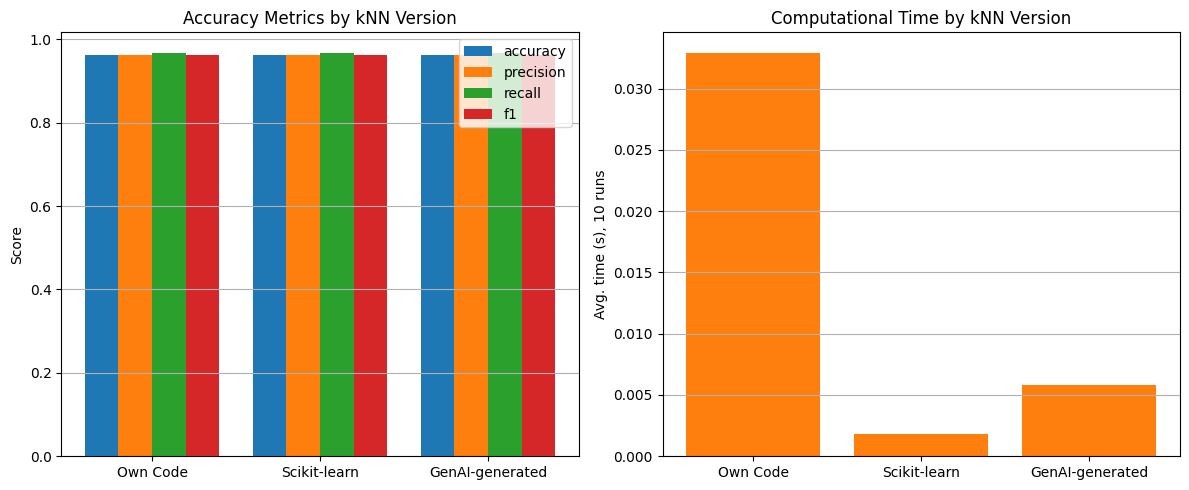

In [14]:
# Bar chart: accuracy/F-score and timing comparison across the 3 versions
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

metrics_to_plot = ["accuracy", "precision", "recall", "f1"]
x = range(len(results_df.index))
width = 0.2
for i, metric in enumerate(metrics_to_plot):
    axes[0].bar([p + i * width for p in x], results_df[metric], width=width, label=metric)
axes[0].set_xticks([p + 1.5 * width for p in x])
axes[0].set_xticklabels(results_df.index)
axes[0].set_ylabel("Score")
axes[0].set_title("Accuracy Metrics by kNN Version")
axes[0].legend()
axes[0].grid(True, axis="y")

axes[1].bar(results_df.index, results_df["avg_time_sec"], color="tab:orange")
axes[1].set_ylabel("Avg. time (s), 10 runs")
axes[1].set_title("Computational Time by kNN Version")
axes[1].grid(True, axis="y")

plt.tight_layout()
plt.savefig("a3_comparison_chart.png", dpi=150)
plt.show()
